In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("feature_engineered_dataset.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (4566, 21)


,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,StreetNameAndWay,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,OwnerLastName,SaleDate,...,TotalAppraisedValue,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,LogSalePrice,SaleYear,SaleMonth,PricePerSqft,AppraisalRatio
0,3,6.0,77,STAFFORD ST,2,6000.0,1092.0,1.0,WRIGHT,2024-07-01 00:00:00+00:00,...,187200,1,10,5,False,12.464587,2024,7,237.179487,1.383547
1,3,3.0,73,STAFFORD ST,2,6000.0,936.0,1.0,SANTANA,2022-04-26 00:00:00+00:00,...,192300,1,10,5,False,12.245298,2022,4,222.222222,1.081643
2,3,6.0,61,STAFFORD ST,2,6000.0,1111.0,1.0,MARTINEZ,2023-12-22 00:00:00+00:00,...,148400,1,10,5,False,11.736077,2023,12,112.511251,0.842318
3,3,6.0,211,NEWINGTON AVE,2,5040.0,1684.0,1.0,CAHUANA FLORES,2021-01-11 00:00:00+00:00,...,197900,1,10,5,False,12.083911,2021,1,105.106888,0.894391
4,3,3.0,18,BRISTOL ST,2,6000.0,900.0,1.0,NEGRON,2021-09-21 00:00:00+00:00,...,170700,1,10,5,False,12.144203,2021,9,208.888889,1.101347


In [2]:
# Feature and Target Selection

# Target variable
y = df['SalePrice']

# Remove target and leakage/unnecessary columns
X = df.drop(columns=[
    'SalePrice',
    'OwnerLastName',
    'StreetNameAndWay',
    'SaleDate',
    'LogSalePrice',
    'PricePerSqft',
    'AppraisalRatio'
], errors='ignore')

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeatures used:")
print(X.columns)

Feature Matrix Shape: (4566, 14)
Target Shape: (4566,)

Features used:
Index(['xrCompositeLandUseID', 'xrBuildingTypeID', 'LocationStartNumber',
       'xrPrimaryNeighborhoodID', 'LandSF', 'TotalFinishedArea', 'LivingUnits',
       'TotalAppraisedValue', 'xrSalesValidityID', 'xrDeedID', 'AssrLandUse',
       'WasZeroPrice', 'SaleYear', 'SaleMonth'],
      dtype='object')


In [3]:
# Encode categorical variables using One-Hot Encoding

X_encoded = pd.get_dummies(X, drop_first=True)

print("Encoded Feature Shape:", X_encoded.shape)

X_encoded.head()

Encoded Feature Shape: (4566, 14)


,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,TotalAppraisedValue,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,SaleYear,SaleMonth
0,3,6.0,77,2,6000.0,1092.0,1.0,187200,1,10,5,False,2024,7
1,3,3.0,73,2,6000.0,936.0,1.0,192300,1,10,5,False,2022,4
2,3,6.0,61,2,6000.0,1111.0,1.0,148400,1,10,5,False,2023,12
3,3,6.0,211,2,5040.0,1684.0,1.0,197900,1,10,5,False,2021,1
4,3,3.0,18,2,6000.0,900.0,1.0,170700,1,10,5,False,2021,9


In [4]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (3652, 14)
Testing set shape: (914, 14)


In [5]:
# Train AdaBoost Regressor

from sklearn.ensemble import AdaBoostRegressor

# Initialize model
ada = AdaBoostRegressor(random_state=42)

# Train model
ada.fit(X_train, y_train)

print("AdaBoost model trained successfully!")

AdaBoost model trained successfully!


In [6]:
# Predict using AdaBoost model

ada_pred = ada.predict(X_test)

print("Predictions completed!")

print("\nFirst 10 Predictions:")
print(ada_pred[:10])

Predictions completed!

First 10 Predictions:
[  269445.36449432   269445.36449432   290706.81044229   269445.36449432
   288687.13351489   313552.83333333 10250144.           290706.81044229
   288687.13351489   269445.36449432]


In [7]:
# Evaluate AdaBoost model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, ada_pred)
rmse = np.sqrt(mean_squared_error(y_test, ada_pred))
r2 = r2_score(y_test, ada_pred)

print("AdaBoost Model Performance")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

AdaBoost Model Performance
MAE: 160537.7536443694
RMSE: 278030.49983279983
R2 Score: 0.9844593039895996


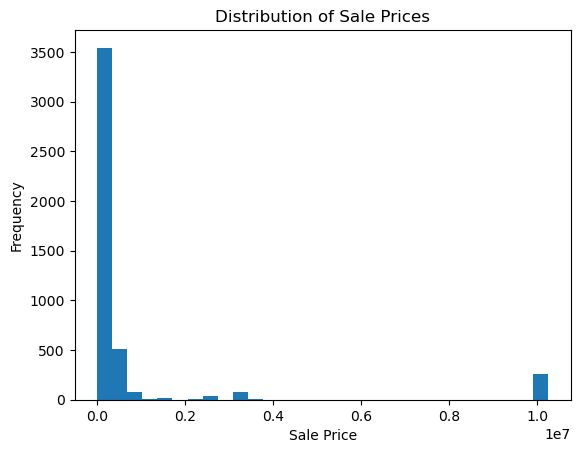

In [8]:
# Histogram of Sale Price Distribution

import matplotlib.pyplot as plt

plt.figure()

plt.hist(df['SalePrice'], bins=30)

plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

### Insight

The histogram shows the distribution of property sale prices in the dataset. 
Most properties are concentrated within a lower to mid price range, while a smaller number of properties have significantly higher sale prices. 
This indicates that the dataset contains a few high-value outliers, which is common in real estate markets.